In [1]:
import sys
sys.path.insert(0, "/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC")
import os
import torch
import numpy as np
import scanpy as sc
import pandas as pd
import argparse
import json
from skimage import filters
import matplotlib.pyplot as plt
import seaborn as sns

from src.deepSCENIC import deepSCENIC

/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (5.1.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "
2024-02-07 15:16:19.324664: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-07 15:16:19.471997: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=

### Load deepSCENIC model

In [2]:
# Output dir of deepSCENIC
DATA_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/'
RES_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/MM_lines_Enformer3/'
parser = argparse.ArgumentParser()
opt = parser.parse_args('')
with open(RES_PATH + "/hyperparma.txt", 'r') as f:
            opt.__dict__.update(json.load(f))

In [8]:
opt.train = False
opt.use_best = True
opt.data_rna_file_test = DATA_PATH + 'raw_exprMat_test.h5ad'
# opt.seqs_batch_size = opt.TF2rNet_batch_size

In [9]:
# Compile model
ds_model = deepSCENIC(opt)
dataloader, TFs_idx, r2g_dist_coo, seq_dataloader, _ = ds_model.init_data()

dir exist
reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12188
    var: 'n_cells'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 281820


### Extract TF2r (TF to region: E1) and r2g (region to gene: E2) matrix

In [10]:
from src.model import VAE
from src.tf2rNet.models import MotifNet, Sei
from enformer_pytorch import Enformer
from tqdm import tqdm
import pickle

ds_model.opt.split_test = False
ds_model.opt.train = False
if opt.use_best==True:
    model_dict_tf2r_func_enc_path = opt.save_name + 'best_model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.save_name + 'best_model_tf2r.pth'
    vae_model_path = opt.save_name + 'best_model.pth'
else:
    model_dict_tf2r_func_enc_path = opt.save_name + 'model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.save_name + 'model_tf2r.pth'
    vae_model_path = opt.save_name + 'model.pth'        


if opt.device=='cuda':
    Tensor = torch.cuda.FloatTensor
elif opt.device=='cpu':
    Tensor = torch.FloatTensor

# adj_E1s = []
# for i in range(10):
with torch.no_grad():
    tf2rNet = MotifNet(ds_model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, dev=opt.device).float().to(opt.device)
    tf2rNet.load_state_dict(torch.load(model_dict_tf2r_path,  map_location=torch.device(opt.device))['model_state_dict'])
    # Initialize Enformer model
    tf2rNet_func_encoder = Enformer.from_pretrained('EleutherAI/enformer-official-rough', target_length=5, dropout_rate = 0.1).to(opt.device)
    tf2rNet_func_encoder.load_state_dict(torch.load(model_dict_tf2r_func_enc_path,  map_location=torch.device(opt.device))['model_state_dict'])
    # vae = VAE(TFs_idx, r2g_dist_coo, 1, model.opt.n_hidden, dev=model.opt.device).float().to(model.opt.device)
    # vae.load_state_dict(torch.load(model.opt.save_name + 'model.pth',  map_location=torch.device(opt.device))['model_state_dict'])


    # Define the concatenated model with a custom forward method
    class ConcatModel(torch.nn.Module):
        def __init__(self, models):
            super(ConcatModel, self).__init__()
            self.models = torch.nn.ModuleList(models)
    
        def forward(self, seq,):
            for model in self.models:
                if isinstance(model, Enformer):
                    x = model(seq, return_only_embeddings=True)
                elif isinstance(model, MotifNet):                 
                    x = model(emb=x)
                    # x = torch.unsqueeze(x, dim=0)
                else:
                    x = model(seq)
            return x

    
    model = ConcatModel([tf2rNet_func_encoder, tf2rNet]).to(opt.device)   
    model.eval()
    # TF2rNet forward pass
    E1 = []
    for j, (seq, seq_data_batch_idx) in tqdm(enumerate(seq_dataloader, 0)):
        X_E1 = model(seq[0].to(opt.device))
        E1.append(X_E1)
    adj_E1 = torch.cat(E1)

1101it [02:11,  8.35it/s]


In [11]:
E1 = pd.DataFrame(adj_E1.T.detach().cpu().numpy(), columns=dataloader['atac_region_name'], index=np.array(dataloader['rna_gene_name'])[TFs_idx])

In [12]:
from scipy.sparse import load_npz

with torch.no_grad():
    vae = VAE(TFs_idx, r2g_dist_coo, 1, ds_model.opt.n_hidden, dev=opt.device).float()
    vae.load_state_dict(torch.load(vae_model_path,  map_location=torch.device('cpu'))['model_state_dict'])
    print("Best training epoch: ", torch.load(vae_model_path)['epoch'])
with torch.no_grad():
    adj_E2_test = torch.load(opt.save_name + '/E2_test.pth')['vae_E2_test']
    r2g_dist = torch.sparse_coo_tensor(torch.tensor([r2g_dist_coo.row.tolist(), r2g_dist_coo.col.tolist()]), torch.tensor(1/r2g_dist_coo.data).float(), r2g_dist_coo.shape, requires_grad=False).coalesce().float()
    E2_train = torch.sparse_coo_tensor(r2g_dist.indices().to(opt.device), vae.adj_E2.abs(), r2g_dist.shape).to_dense()
    r2g_dist_coo_test = load_npz('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/r2gpenalty_test.npz')
    r2g_dist_test = torch.sparse_coo_tensor(torch.tensor([r2g_dist_coo_test.row.tolist(), r2g_dist_coo_test.col.tolist()]), torch.tensor(1/r2g_dist_coo_test.data).float(), r2g_dist_coo_test.shape, requires_grad=False).coalesce().float()
    E2_test = torch.sparse_coo_tensor(r2g_dist_test.indices().to(opt.device), adj_E2_test.abs(), r2g_dist_test.shape).to_dense()
    

Best training epoch:  832


In [13]:
E2_train = pd.DataFrame(E2_train.cpu().numpy(), columns=sc.read(opt.data_rna_file_train).var_names, index=sc.read(opt.data_atac_file_train).var_names)
E2_test = pd.DataFrame(E2_test.cpu().numpy(), columns=sc.read(opt.data_rna_file_test).var_names, index=sc.read(opt.data_atac_file_test).var_names)

In [14]:
E2_test = E2_test.iloc[:, np.where(E2_test.sum(0)!=0)[0]]
E2_train = E2_train.loc[:, ~E2_train.columns.isin(E2_test)]
E2 = pd.merge(E2_train, E2_test, left_index=True, right_index=True, how='outer')
E2 = E2.fillna(0)
E2 = E2.loc[dataloader['atac_region_name'], dataloader['rna_gene_name']]

In [15]:
# Save matrices
E1.to_pickle(RES_PATH + 'E1.pkl')
E2.to_pickle(RES_PATH + 'E2.pkl') 

# Extract TF, enhancer activities and other latent representations

In [16]:
with torch.no_grad():
    E2 = torch.tensor(pd.read_pickle(RES_PATH + 'E2.pkl').values).to(opt.device)
    E1 = torch.tensor(pd.read_pickle(RES_PATH + 'E1.pkl').values).to(opt.device)
ds_model.to_latent(adj_E1=E1.T, adj_E2=E2)

reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12188
    var: 'n_cells'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 281820
loaded weights for TF2rNet
VAE forward...


100%|██████████| 59/59 [00:03<00:00, 19.64batch/s]


In [17]:
# Read gene expression data and cell annotations
ad = sc.read(opt.data_rna_file)
cells_metadata = pd.read_csv(DATA_PATH + '/cells_metadata.csv', index_col=0)
ad.obs[cells_metadata.columns] = cells_metadata.loc[ad.obs.index,:].values

# Load latent representations
ad.obsm['z_rna'] = np.load(opt.save_name + 'z_rna.npy', allow_pickle=True) # Latent target gene expression
ad.obsm['y_rna'] = np.load(opt.save_name + 'y_rna.npy', allow_pickle=True) # Predicted target gene expression\
ad.obsm['y_atac'] = np.load(opt.save_name + 'y_atac.npy', allow_pickle=True) # Predicted chromatin accessibility
ad.obsm['enh_act'] = np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True) # Predicted enhancer activity
ad.obsm['tf_act'] = np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True) # Predicted TF activity

ad

AnnData object with n_obs × n_vars = 936 × 12188
    obs: 'MMline', 'lineState'
    var: 'n_cells'
    obsm: 'z_rna', 'y_rna', 'y_atac', 'enh_act', 'tf_act'
    layers: 'log_norm'

         Falling back to preprocessing with `sc.pp.pca` and default params.


/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


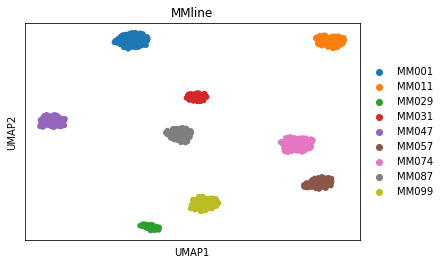

In [18]:
# UMAP of input TF expression
ad_tf = ad[:, TFs_idx].copy()
sc.pp.neighbors(ad_tf, n_pcs=50)
sc.tl.umap(ad_tf)
sc.pl.umap(ad_tf, color=['MMline'])

         Falling back to preprocessing with `sc.pp.pca` and default params.


/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


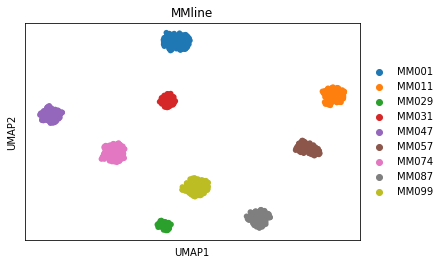

In [19]:
# UMAP of input target gene expression
sc.pp.neighbors(ad, n_pcs=50)
sc.tl.umap(ad)
sc.pl.umap(ad, color=['MMline'])
ad.obsm['X_rna_umap'] = ad.obsm['X_umap']

/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:260: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


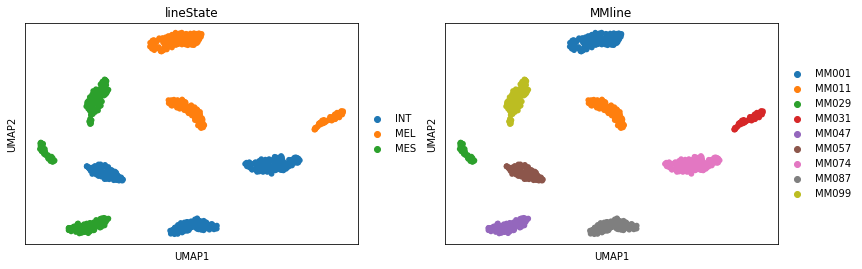

In [20]:
# UMAP of enhancer activity
sc.pp.neighbors(ad, use_rep='enh_act', key_added="enh_act")
sc.tl.umap(ad,  neighbors_key='enh_act')
sc.pl.umap(ad, color=['lineState', 'MMline'])
ad.obsm['X_enh_act_umap'] = ad.obsm['X_umap']

### Building eGRN 

Select eRegulons

In [21]:
# Load tfs-regions and regions-genes interaction matrices
E1 = pd.read_pickle(RES_PATH + 'E1.pkl')
E2 = pd.read_pickle(RES_PATH + 'E2.pkl')

In [22]:
# Building AnnData objects containing enhancer activity and TFs activity profiles for each cell
ad_enahancer = sc.AnnData(np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True), obs=ad.obs)
ad_enahancer.var_names = sc.read(opt.data_atac_file).var_names

ad_tf = sc.AnnData(np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True), obs=ad.obs)
ad_tf.var_names = sc.read(opt.data_rna_file).var_names[TFs_idx]

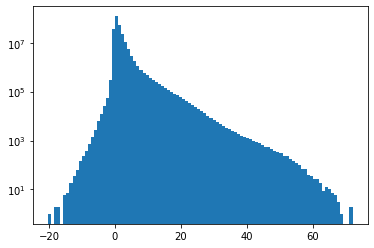

In [23]:
# Plot distribution of enhancer activities
plt.hist(ad_enahancer.X[ad_enahancer.X!=0], bins=100);
plt.yscale('log')

In [27]:
# Building dataframe of enhancer activity profiles per cell-type
df_enancher_activity =[]
for line in ad.obs.MMline.unique():
    df_enancher_activity.append(ad_enahancer[ad_enahancer.obs.MMline==line].to_df().mean(0))
df_enancher_activity = pd.concat(df_enancher_activity, axis=1, keys=ad.obs.MMline.unique())

In [28]:
df_enancher_activity

,MM001,MM011,MM029,MM031,MM047,MM057,MM074,MM087,MM099
chr10:100004862-100005362,0.220411,-0.047779,0.160943,-0.109789,0.365761,0.063856,0.096017,0.182671,0.371563
chr10:100005406-100005906,0.273248,0.430285,0.198945,0.595064,0.335943,-0.183848,0.245040,0.237671,0.189608
chr10:100008095-100008595,0.272711,0.093677,0.472237,0.054983,0.267691,0.548620,0.471666,0.213310,0.831955
chr10:100019819-100020319,1.589371,0.811225,0.350981,0.741380,0.514800,1.231198,0.543525,0.897527,0.504605
chr10:100021442-100021942,0.460981,0.917087,0.420243,0.661280,0.498361,0.009048,0.537859,0.662452,0.211542
...,...,...,...,...,...,...,...,...,...
chr18:9961076-9961576,1.063687,0.473972,0.540929,0.989804,0.418001,0.621285,0.481985,0.509803,0.245696
chr18:9966058-9966558,0.250486,0.174216,3.149515,0.942219,2.214265,0.735234,1.074801,0.548142,2.438965
chr18:9971272-9971772,2.319397,1.962466,1.926136,3.034011,1.986913,2.122693,3.213326,1.962818,1.773231
chr18:998823-999323,1.004886,0.756696,0.938358,0.607853,0.906820,0.727330,0.473508,0.750062,1.252598


In [30]:
# Threshold enhancer activity profiles per cell-type and compute TFs activity average profiles
df_tf_activity =[]
active_enhancers_l = []
for line in ad.obs.MMline.unique():
    active_enhancers = df_enancher_activity.loc[:, line].abs()
    th = filters.threshold_otsu(active_enhancers.values)
    active_enhancers = active_enhancers[active_enhancers>th]
    active_enhancers_l.append(active_enhancers.index.to_list())
    df_tf_activity.append((ad_tf[ad_tf.obs.MMline==line, :].X.mean(0)[:,None] * E1.loc[:, active_enhancers.index]).abs().mean(1)) # TFs activity average profiles
    
df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.MMline.unique())    

In [31]:
# Threshold TFs activity profiles and extract key TFs per cell-type
TFs = []
for line in ad.obs.MMline.unique():
    df_line = df_tf_activity.loc[:,line].abs()
    th = filters.threshold_otsu(df_line.values)
    TFs.extend(df_line[df_line > th].index.to_list())

# Subset TF-region interaction matrix to key TFs
E1_sub = E1.loc[list(set(TFs)), :]

In [32]:
# Build eGRN
from joblib import Parallel, delayed
from tqdm import tqdm
from skimage import filters

r2g_th=0
def tf_df(E1, E2, tf):
    TFs, regions, target_genes, tf2r_scores, r2g_scores, tf2g_scores = [], [], [], [], [], []

    E1_tf = E1.loc[tf,:][E1.abs().loc[tf,:]>0].abs()
    if E1_tf.shape[0]>0:
        tf2r_th = filters.threshold_otsu(E1_tf.values) # Threshold TF-region interaction scores per TF
        regs = E1.loc[tf,:][E1.abs().loc[tf,:] > tf2r_th].index
        for r in regs:
            E2_r = E2.loc[r, :][E2.loc[r, :]>0]
            if E2_r.shape[0]>0:
                # r2g_th = filters.threshold_otsu(E2_r.values)
                targets = E2.loc[r, :][E2.loc[r, :] > r2g_th].index
                for g in targets:            
                    TFs.append(tf)
                    regions.append(r)
                    target_genes.append(g)
                    tf2r_scores.append(E1.loc[tf,r])
                    tf2g_scores.append(E1.loc[tf,r]*E2.loc[r,g])
                    r2g_scores.append(E2.loc[r,g])

    return TFs, regions, target_genes, tf2r_scores, tf2g_scores, r2g_scores

res = Parallel(n_jobs=32)(delayed(tf_df)(E1_sub, E2, tf) for tf in tqdm(E1_sub.index))

TFs, regions, target_genes, tf2r_scores, tf2g_scores, r2g_scores = [], [], [], [], [], []
for i in tqdm(range(len(res))):
    TFs.extend(res[i][0])
    regions.extend(res[i][1])
    target_genes.extend(res[i][2])
    tf2r_scores.extend(res[i][3])
    tf2g_scores.extend(res[i][4])
    r2g_scores.extend(res[i][5])

df_deepSCENIC_grn = pd.DataFrame({'TF':TFs, 'region':regions, 'gene':target_genes, 'tf2r_score':tf2r_scores, 'tf2g_score':tf2g_scores , 'r2g_score':r2g_scores})
df_deepSCENIC_grn.to_pickle(RES_PATH + '/df_deepSCENIC_grn.pkl')
df_deepSCENIC_grn    

100%|██████████| 72/72 [00:00<00:00, 150.35it/s]


,TF,region,gene,tf2r_score,tf2g_score,r2g_score
0,HIF1A,chr10:100579351-100579851,ABCC2,0.064901,3.575909e-05,0.000551
1,HIF1A,chr10:100579351-100579851,BLOC1S2,0.064901,3.167085e-05,0.000488
2,HIF1A,chr10:100579351-100579851,BTRC,0.064901,9.927054e-06,0.000153
3,HIF1A,chr10:100579351-100579851,CHUK,0.064901,1.993706e-06,0.000031
4,HIF1A,chr10:100579351-100579851,COX15,0.064901,2.558105e-04,0.003942
...,...,...,...,...,...,...
11975602,POLE4,chr18:9988627-9989127,PPP4R1,-0.048530,-4.536317e-07,0.000009
11975603,POLE4,chr18:9988627-9989127,RAB31,-0.048530,-1.236363e-04,0.002548
11975604,POLE4,chr18:9988627-9989127,RALBP1,-0.048530,-1.300507e-04,0.002680
11975605,POLE4,chr18:9988627-9989127,TWSG1,-0.048530,-1.808551e-04,0.003727


### Extract differentially active enhancers between cell-type

In [42]:
sc.tl.rank_genes_groups(ad_enahancer, 'lineState', method='wilcoxon')

/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


In [43]:
# Differntially positve enhancers
DE_enahncer = pd.DataFrame(ad_enahancer.uns['rank_genes_groups']['names'])
DE_enahncer.index = ad_enahancer.var_names
DE_enahncer

,INT,MEL,MES
chr10:100004862-100005362,chr11:112582334-112582834,chr7:2427325-2427825,chr2:168816339-168816839
chr10:100005406-100005906,chr2:70592581-70593081,chr3:23069689-23070189,chr17:55086527-55087027
chr10:100008095-100008595,chr7:10913499-10913999,chr3:45041416-45041916,chr2:180000380-180000880
chr10:100019819-100020319,chr13:49083146-49083646,chr17:63551744-63552244,chr2:179837342-179837842
chr10:100021442-100021942,chr6:88989103-88989603,chr10:90912206-90912706,chr7:130916412-130916912
...,...,...,...
chr18:9961076-9961576,chr6:13729106-13729606,chr7:11331062-11331562,chr20:11473957-11474457
chr18:9966058-9966558,chr3:33916135-33916635,chr15:66269631-66270131,chr20:1144505-1145005
chr18:9971272-9971772,chr6:139762475-139762975,chr9:68552637-68553137,chr20:11352046-11352546
chr18:998823-999323,chr6:45209701-45210201,chr6:63740670-63741170,chr20:11351052-11351552


In [54]:
n_enhancers = 1000
markers = []
for line in ad.obs.lineState.unique():
    # markers.append(df_enancher_activity.loc[:,line].sort_values(ascending=False)[:n_enhancers].index.values)
    markers.append(DE_enahncer.loc[:,line][:n_enhancers].values)

### Extract keys TFs per cell-type

1. Most active TFs in differentially active enhancers

In [55]:
d = dict(ad_tf.obs.drop_duplicates('MMline').values)
# Extract TF activities on top DA positive enhancers per cell-type
# n_enhancers = 1000
df_tf_activity =[]
for line in ad.obs.MMline.unique():
    df_tf_activity.append((ad_tf[ad_tf.obs.MMline==line, :].X.mean(0)[:,None] * E1.loc[:, DE_enahncer.loc[:, d[line]][:n_enhancers]]).mean(1))

df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.MMline.unique())    

In [56]:
# Extract top activators per cell-type
n_TFs = 20
markers = []
markers_MES = []
for line in ad.obs.MMline.unique():
    markers.append(df_tf_activity.loc[:,line].abs().sort_values(ascending=False)[:n_TFs].index.values)
    if line in ['MM029', 'MM047', 'MM099']:
        markers_MES.append(df_tf_activity.loc[:,line].abs().sort_values(ascending=False)[:n_TFs].index.values)

In [57]:
lines_order = ['MM001', 'MM011', 'MM031', 'MM087', 'MM074', 'MM057', 'MM029', 'MM047', 'MM099']
d_col_state = dict(zip(ad.obs.lineState.cat.categories, ad.uns['lineState_colors']))
d_col_line = dict(zip(ad.obs.MMline.cat.categories, ad.uns['MMline_colors']))
df_tf_activity = df_tf_activity.loc[list(set(np.concatenate(markers))) + ['TCF4'], lines_order].T

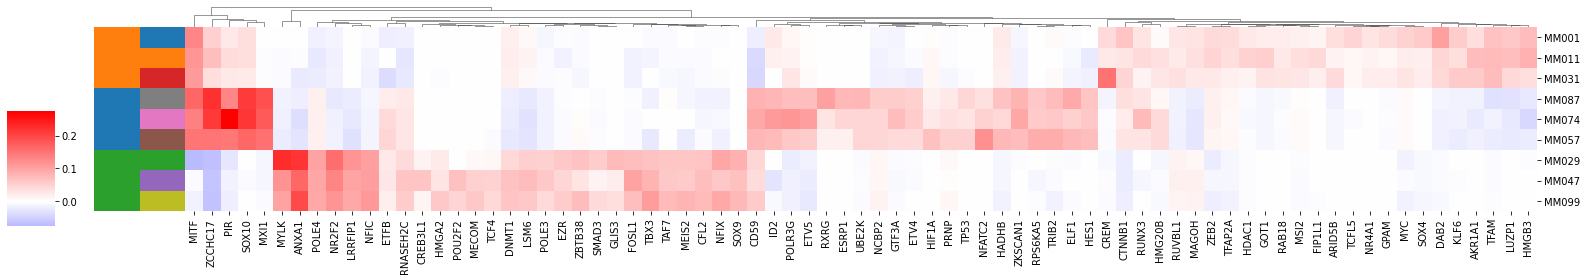

In [58]:
sns.clustermap(df_tf_activity,
               row_cluster=False, 
               cmap='bwr', 
               center=0, 
               figsize=(22,4), 
               xticklabels=True, 
               dendrogram_ratio=(0.05, .1),
               cbar_pos=(0, .2, .03, .4),
               method='average',
               # metric='correlation',
               row_colors=[df_tf_activity.index.map(d).map(d_col_state), df_tf_activity.index.map(d_col_line)],
              )